In [19]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

import sys
import copy

import anndata
import cassiopeia as cas
# import cv2
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import numba
import pandas as pd
import scanpy as sc
import scipy
from scipy.ndimage import rotate
from scipy import optimize, spatial
import seaborn as sns
import squidpy as sq
from tqdm import tqdm

SPATIAL_PACKAGE = "/path/to/spatial/package/"
DATA_DIR = "/path/to/kpspatial/data/"

sys.path.append(SPATIAL_PACKAGE)
from utilities import target_site_utilities, spatial_utilities, reconstruct, tree_utilities, colors

In [4]:
def read_in_allele_table(allele_table_paths, keep_ambiguous=True, min_ts_umi=3, min_intbc_umi=2):

    to_merge = []
    
    for sample, allele_table_path in zip(allele_table_paths.keys(), allele_table_paths.values()):
        at = pd.read_csv(allele_table_path, sep='\t')
        at['cellBC'] = at.apply(lambda x: f'{sample}.{x.cellBC}', axis=1)
        at['sample'] = sample 
    
        cellbc_umi = at.groupby('cellBC').agg({'UMI': 'sum'})

        at = at[at['cellBC'].isin(cellbc_umi[cellbc_umi['UMI'] >= min_ts_umi].index.values)]
        at = at[at['UMI'] >= min_intbc_umi]
    
        at = at[~at[['r1', 'r2', 'r3']].isna().any(axis=1)]
        if not keep_ambiguous:
            at = at.sort_values(
                ["UMI", "readCount"], ascending=False
            ).drop_duplicates(["cellBC", "intBC"])

        to_merge.append(at)

    final_at = pd.concat(to_merge)

    return final_at.reset_index()

def get_phylogenetic_distance_matrix(tree, branch_lengths=True, use_priors=False):

    subtree = tree.copy()

    if not use_priors:
        subtree.priors = None

    if branch_lengths:
        for edge in subtree.depth_first_traverse_edges():
            branch_length = len(subtree.get_mutations_along_edge(edge[0], edge[1]))
            subtree.set_branch_length(edge[0], edge[1], branch_length)
        
    distances = dict(nx.all_pairs_dijkstra_path_length(subtree.get_tree_topology().to_undirected(), weight='length'))
    phylogenetic_distance_matrix = pd.DataFrame.from_dict(distances)
    phylogenetic_distance_matrix = phylogenetic_distance_matrix.loc[tree.leaves, tree.leaves]

    np.fill_diagonal(phylogenetic_distance_matrix.values, 0)

    return phylogenetic_distance_matrix

@numba.jit(nopython=True)
def min_net_relatedness_index(
    dissimilarity_map: np.array, indices_1: np.array, indices_2: np.array
) -> float:
    """Computes the min linkage relatedness index between indices.

    Args:
        dissimilarity_map: Dissimilarity map between all samples.
        indices_1: Indices corresponding to the first group.
        indices_2: Indices corresponding to the second group.

    Returns:
        The Mininum Net Relatedness Index
    """

    val = 0
    for i in indices_1:
        val += np.min(dissimilarity_map[i,indices_2])
                      
    return val / len(indices_1)

## Register across layers

In [5]:
hotspot_scores = pd.read_csv(f"{DATA_DIR}/slideseq/hotspot/hotspot_modules_consensus.scores.tsv", sep='\t', index_col = 0)
hotspot_scores.index = hotspot_scores.apply(lambda x: f'{x.Sample}.{x.name}', axis=1)

hotspot_scores.head(5)

,Joint_Module_6,Joint_Module_2,Joint_Module_3,Joint_Module_5,Joint_Module_1,Joint_Module_11,Joint_Module_4,Joint_Module_7,Joint_Module_8,Joint_Module_10,Joint_Module_9,Sample
M18_01.AAAAATNAAACCAG,0.024362,0.076691,0.106999,0.168335,-0.152229,-0.054039,0.220815,-0.038360,-0.076549,0.107414,-0.082653,M18_01
M18_01.AAANACAAAATAGA,0.110122,-0.003375,-0.078438,-0.008844,0.021297,0.051976,-0.162382,0.182293,0.014471,0.129887,-0.068416,M18_01
M18_01.AAAAANTAAATTGA,-0.105580,-0.033142,-0.051942,-0.097325,-0.040726,-0.077401,0.059919,0.006306,-0.036873,-0.034693,-0.072624,M18_01
M18_01.AAANACAATAACAG,-0.129291,-0.058670,-0.024205,-0.153559,0.188195,-0.019283,-0.104308,-0.173507,-0.058034,0.101211,-0.109423,M18_01
M18_01.AAATANACTTTTCT,0.039271,0.206507,0.021547,-0.080201,-0.083716,0.033781,-0.040289,0.179095,0.064162,-0.005607,0.064683,M18_01


In [15]:
SAMPLES=['Layer1/Curio_001', 'Layer2/Curio_002', 'Layer3/Curio_003', 'Layer4/Curio_004',
        'Layer1/M18_01', 'Layer1/M18_02', 'Layer1/M18_04',
        'Layer2/M18_06', 'Layer2/M11_06',
        'Layer3/M18_17', 'Layer3/M11_08',
        'Layer4/M11_14', 'Layer4/M18_13']

KEEP_AMBIGUOUS = False

MIN_SPOT_UMI_SUPPORT = 1
MIN_TS_UMI_SUPPORT = 1
DOWNSAMPLE=None
subtumor = {}

adata_dict, at_to_merge = {}, []
adata_to_combine = []
for i, sample in zip(range(len(SAMPLES)), SAMPLES):
    
    print(sample)
         
    sample_name = sample.split("/")[1]

    adata = sc.read_h5ad(f'{DATA_DIR}/slideseq/expression/{sample_name}_adata.h5ad')
    adata.var_names = adata.var_names.astype(str)
    adata.var_names_make_unique()
    adata.obs_names = [f'{sample_name}.{cellbc}' for cellbc in adata.obs_names]
    
    allele_table = pd.read_csv(f'{DATA_DIR}/slideseq/trees/{sample_name}_allele_table.tsv', sep='\t')
    allele_table['cellBC'] = allele_table.apply(lambda x: f"{sample_name}.{x.cellBC}", axis=1)
    allele_table['Puck'] = sample_name

    spot_umis = allele_table.groupby('cellBC').agg({'UMI': 'sum'})
    keep_cells = spot_umis.index[np.where(spot_umis.values > MIN_SPOT_UMI_SUPPORT)[0]]
    allele_table = allele_table[allele_table['cellBC'].isin(keep_cells)] 
    allele_table = allele_table[allele_table['UMI'] >= MIN_TS_UMI_SUPPORT]

    overlapping = np.intersect1d(adata.obs_names, allele_table['cellBC'].unique())
    allele_table = allele_table[allele_table['cellBC'].isin(overlapping)]
    
    tumor_id_map = dict(zip(adata.obs_names, [f'{sample_name}.{_id}' for _id in adata.obs['tumor_id']]))
    adata.obs['tumor_id_full'] = adata.obs_names.map(tumor_id_map)
    allele_table['tumor_id'] = allele_table['cellBC'].map(tumor_id_map)
    
    adata.obs['library_id'] = sample_name
    
    adata_to_combine.append(adata)

    at_to_merge.append(allele_table)

adata_combined = anndata.concat(adata_to_combine)
at_combined = pd.concat(at_to_merge).reset_index()
at_combined = at_combined[~at_combined[['r1', 'r2', 'r3']].isna().any(axis=1)]
if not KEEP_AMBIGUOUS:
    at_combined = at_combined.sort_values(
        ["UMI", "readCount"], ascending=False
    ).drop_duplicates(["cellBC", "intBC"])

print(f'Read in {adata_combined.shape[0]} spots.')

Layer1/Curio_001
Layer2/Curio_002
Layer3/Curio_003
Layer4/Curio_004
Layer1/M18_01
Layer1/M18_02
Layer1/M18_04
Layer2/M18_06
Layer2/M11_06
Layer3/M18_17
Layer3/M11_08
Layer4/M11_14
Layer4/M18_13
Read in 1712874 spots.


In [16]:
adata_combined.obs['library_id'] = adata_combined.obs['library_id'].astype('category')
sq.gr.spatial_neighbors(adata_combined, spatial_key='spatial', library_key='library_id', radius=30, delaunay=True, coord_type='generic')
adata_combined.obs['library_id'].unique()

INFO     Creating graph using `generic` coordinates and `None` transform and `13` libraries.                       


['Curio_001', 'Curio_002', 'Curio_003', 'Curio_004', 'M18_01', ..., 'M11_06', 'M18_17', 'M11_08', 'M11_14', 'M18_13']
Length: 13
Categories (13, object): ['Curio_001', 'Curio_002', 'Curio_003', 'Curio_004', ..., 'M18_04', 'M18_06', 'M18_13', 'M18_17']

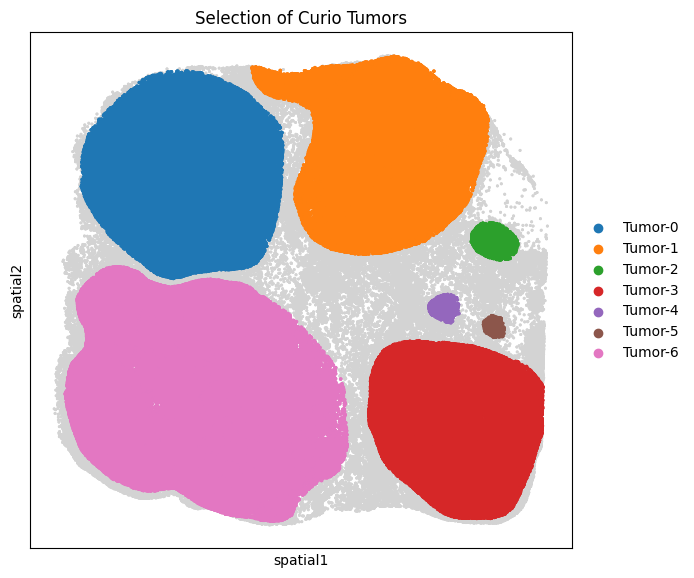

In [17]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
sq.pl.spatial_scatter(adata_combined, library_key='library_id', library_id='Curio_003', size=5, shape=None, na_color='lightgray', ax=ax, figsize=(7,7), legend_loc=None)
sq.pl.spatial_scatter(adata_combined, library_key='library_id', library_id='Curio_003', color=['tumor_id'],
                      groups = [tumor for tumor in adata_combined.obs['tumor_id'].unique() if tumor != 'non-tumor'],
                      # groups = ['Tumor-2'],
                      size=10, ax=ax, shape=None)
plt.gca().invert_yaxis()
plt.title(f'Selection of Curio Tumors')
plt.show()

In [18]:
at_combined['tumor_id'].unique()
at_combined_filtered = at_combined[at_combined.apply(lambda x: 'non-tumor' not in x.tumor_id, axis=1)]

In [10]:
character_matrix, prior_probs, indel_to_charstate = reconstruct.create_character_matrix(
                                                                          "", "",
                                                                          adata_combined,
                                                                          at_combined_filtered.copy(),
                                                                          "/Users/matthewjones/projects/kptc_spatial/data/allele_priors.tsv",
                                                                          resolve=False,
                                                                          collapse=True,
                                                                          max_missing=1.0,
                                                                          minimum_percent_uncut=0.8,
                                                                          minimum_intbc_umi_support=5,
                                                                          minimum_spot_umi_support=7,
                                                                          # minimum_spot_umi_support=5,
                                                                          # minimum_intbc_umi_support=5,
                                                                          output_path=None,
                                                                          allele_rep_threshold=1.0,
                                                                          impute=False,
                                                                          neighborhood_radius=50.0,
                                                                          # find_neighbors=False,
                                                                          imputation_hops=1,
                                                                          imputation_concordance=0.8,
                                                                          num_imputation_iterations=5)


pre_filtered = character_matrix.shape[0]

# drop data with high missingness and high uncut
MAX_MISSING_THRESH = 0.7
MAX_UNCUT_THRESH = 0.8
character_matrix= character_matrix[((character_matrix == -1).sum(axis=1) / character_matrix.shape[1]) < MAX_MISSING_THRESH]
character_matrix = character_matrix[((character_matrix == 0).sum(axis=1) / (character_matrix != -1).sum(axis=1)) < MAX_UNCUT_THRESH]

# drop duplicates
# character_matrix.drop_duplicates(inplace=True)

print(f"Filtered down to {character_matrix.shape[0]} cells from {pre_filtered}.")

>> Filtering out spots with fewer than 0.8% uncut sites and {minimum_spot_umi_support} UMIs.
>> Filtering out intBCs with fewer than 5 UMIs.
Dropping the following intBCs due to lack of diversity with threshold 1.0: []


Processing characters:   0%|          | 0/30 [00:00<?, ?it/s]

Filtered down to 48428 cells from 59519.


In [12]:
tree = cas.data.CassiopeiaTree(character_matrix)

In [15]:
def random_solver(tree):

    root = 'root'
    random_tree = nx.DiGraph()
    random_tree.add_edges_from([(root, l) for l in tree.character_matrix.index])
    tree.populate_tree(random_tree)

    return tree

In [16]:
print("Computing dissimilarity matrix...")
tree.compute_dissimilarity_map(cas.solver.dissimilarity.weighted_hamming_distance, threads=10)

# solver = cas.solver.NeighborJoiningSolver(add_root=True, fast=True)
solver = cas.solver.VanillaGreedySolver()

print("Solving tree...")
tree = random_solver(tree)
# solver.solve(tree)

print("Collapsing edges...")
tree.collapse_mutationless_edges(infer_ancestral_characters=True)

Computing dissimilarity matrix...
Solving tree...
Collapsing edges...


In [17]:
meta = at_combined_filtered[['cellBC', 'Puck', 'tumor_id']].drop_duplicates().set_index('cellBC')
meta.head(5)

,Puck,tumor_id
cellBC,,
M18_04.CGGTTCACCTGAAT,M18_04,M18_04.Tumor-0
M18_04.AGGAGCAGAAGGCG,M18_04,M18_04.Tumor-0
M18_04.CGGTATTGGTTGGT,M18_04,M18_04.Tumor-0
M18_04.GGGGTGTACGGACG,M18_04,M18_04.Tumor-0
M18_04.AATGGAACTCGCGC,M18_04,M18_04.Tumor-0


In [21]:
subtree = tree.copy()

subtree.cell_meta = pd.DataFrame(index=subtree.leaves)
subtree.cell_meta['Puck'] = meta.loc[tree.leaves, 'Puck']
subtree.cell_meta['Tumor'] = meta.loc[tree.leaves, 'tumor_id']

drop_tumors = ['Curio_002.Tumor-2', 'Curio_003.Tumor-2', 'Curio_004.Tumor-2']
to_drop = subtree.cell_meta[subtree.cell_meta['Tumor'].isin(drop_tumors)].index.values
subtree.remove_leaves_and_prune_lineages(to_drop)

print(subtree.cell_meta['Tumor'].value_counts())
print(subtree.cell_meta['Tumor'].value_counts() / len(subtree.leaves))

# print('Computing phylogenetic distances...')
# dissimilarity_map = get_phylogenetic_distance_matrix(tree)

# tree.compute_dissimilarity_map(cas.solver.dissimilarity.hamming_similarity_normalized_over_missing, threads=10)
dissimilarity_map = tree.get_dissimilarity_map()

evolutionary_coupling = cas.tools.compute_evolutionary_coupling(subtree,
                                                                'Tumor',
                                                                minimum_proportion=0.0002,
                                                                number_of_shuffles=100,
                                                                random_state=np.random.RandomState(124493),
                                                                dissimilarity_map=dissimilarity_map)

Tumor
M18_04.Tumor-0       4811
M11_14.Tumor-0       4736
M11_06.Tumor-0       3568
M11_06.Tumor-1       3301
M11_08.Tumor-0       2962
M18_02.Tumor-1       2756
Curio_001.Tumor-2    2608
M18_01.Tumor-0       2093
M11_14.Tumor-1       2071
M18_06.Tumor-0       1999
M11_08.Tumor-1       1982
Curio_004.Tumor-4    1885
Curio_003.Tumor-3    1824
Curio_003.Tumor-6    1623
M18_17.Tumor-0       1585
Curio_002.Tumor-0    1455
Curio_004.Tumor-1    1117
Curio_002.Tumor-4    1023
M18_06.Tumor-1       1008
Curio_003.Tumor-0     951
Curio_002.Tumor-3     874
Curio_003.Tumor-1     443
M18_02.Tumor-0        428
M18_13.Tumor-0        410
M18_01.Tumor-1        369
M18_17.Tumor-2        167
Curio_002.Tumor-1      85
Curio_001.Tumor-0      74
M18_13.Tumor-2         61
M18_17.Tumor-1         40
Curio_004.Tumor-0      31
Curio_004.Tumor-3      23
M18_13.Tumor-1          9
Curio_003.Tumor-5       2
Curio_001.Tumor-1       1
Name: count, dtype: int64
Tumor
M18_04.Tumor-0       0.099452
M11_14.Tumor-0       0

Creating empirical background: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [28:49<00:00, 17.30s/it]


In [22]:
evolutionary_coupling.fillna(0,inplace=True)

In [24]:
def compute_cell_type_distance(group1, group2, meta):

    abundances_1 = np.array(meta.loc[group1].mean(axis=0))
    abundances_2 = np.array(meta.loc[group2].mean(axis=0))

    return np.sqrt( np.sum( (abundances_1 - abundances_2)**2 ) )

tumor_groups = evolutionary_coupling.columns
cell_type_dists = pd.DataFrame(index=tumor_groups, columns=tumor_groups)

for t1 in tumor_groups:

    g1 = meta.loc[meta['tumor_id'] == t1,:].index.values
    for t2 in tumor_groups:

        g2 = meta.loc[meta['tumor_id'] == t2,:].index.values

        cell_type_difference = compute_cell_type_distance(g1, g2, adata_combined.obs[ct_list])
        cell_type_dists.loc[t1, t2] = cell_type_difference

In [25]:
scaled_evolutionary_coupling = np.exp(-evolutionary_coupling / evolutionary_coupling.abs().max().max())

## Figure 5b

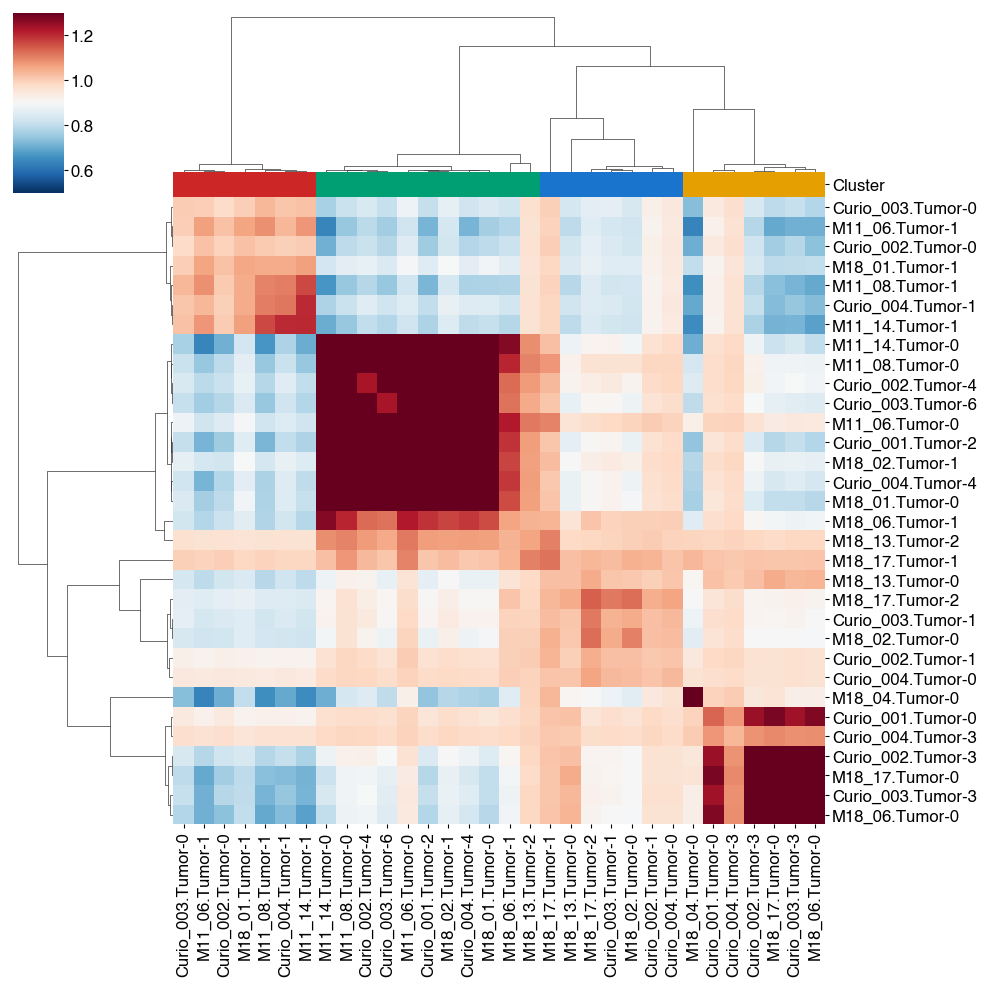

In [28]:
import mplscience
_metric = 'correlation'
_method = 'complete'

hierarchy = scipy.cluster.hierarchy.linkage(
    scipy.spatial.distance.pdist(scaled_evolutionary_coupling.astype(float), metric=_metric),
    method=_method)

hierarchical_clusters = scipy.cluster.hierarchy.fcluster(hierarchy, t=4, criterion="maxclust")

posthoc_merge = {}
# posthoc_merge = {7:4, 6:5}
module_to_cluster = {}
for i, module in zip(range(len(scaled_evolutionary_coupling.index)), scaled_evolutionary_coupling.index):
    assignment = hierarchical_clusters[i]
    if hierarchical_clusters[i] in posthoc_merge:
        assignment = posthoc_merge[hierarchical_clusters[i]]
    module_to_cluster[module] = assignment

palette = ["", "#CD2626", "#009E73", "#1874CD", "#E69F00"]
colors = pd.DataFrame.from_dict({tumor: palette[module_to_cluster[tumor]] for tumor in scaled_evolutionary_coupling.index}, orient='index', columns = ['Cluster'])

with mplscience.style_context():
    
    sns.clustermap(scaled_evolutionary_coupling.astype(float),
                   z_score=None,
                   robust=True,
                   cmap='RdBu_r',
                   # cmap=sns.color_palette("blend:#FFFFFF,#febb81,#f8765c,#d3436e,#982d80,#5f187f,#221150",as_cmap=True),
                   vmax=1.3,
                   vmin=0.5,
                   metric=_metric,
                   method=_method,
                   col_linkage=hierarchy,
                   row_cluster=True,
                   col_colors=colors['Cluster'],
                   annot_kws={'font-size': 3},
                   xticklabels=True,
                   yticklabels=True,
                )
    plt.show()

In [29]:
adata_combined.obs['tumor_id-remapped'] = 'Unmapped'
adata_combined.obs.loc[adata_combined.obs['tumor_id'] == 'non-tumor', 'tumor_id-remapped'] = 'non-tumor'

adata_combined.obs['tumor_id-remapped'] = adata_combined.obs['tumor_id-remapped'].astype(str)

for tumor in module_to_cluster.keys():
    
    puck, orig_tumor = tumor.split(".")[0], tumor.split(".")[1]
    adata_combined.obs.loc[(adata_combined.obs['library_id'] == puck) & (adata_combined.obs['tumor_id'] == orig_tumor), 'tumor_id-remapped'] = f'Tumor-{module_to_cluster[tumor]}'

adata_combined.obs['tumor_id-remapped'] = adata_combined.obs['tumor_id-remapped'].astype('category')
# adata_combined.uns['tumor_id-remapped_colors'] = ["#CD2626", "#009E73", "#1874CD", "#E69F00", "#7C0EDD", "#808080", "#7F0303"]
adata_combined.uns['tumor_id-remapped_colors'] = ["#CD2626", "#009E73", "#1874CD", "#E69F00", "#808080", "#7C0EDD"]

print(adata_combined.obs['tumor_id-remapped'].cat.categories)

Index(['Tumor-1', 'Tumor-2', 'Tumor-3', 'Tumor-4', 'Unmapped', 'non-tumor'], dtype='object')


In [30]:
adata_combined

AnnData object with n_obs × n_vars = 1781399 × 1660
    obs: 'TS-UMI', 'N_intBC', 'TS-ReadCount', 'N_unique_alleles', 'PercentUncut', 'targetsite', 'tumor', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', '_indices', 'Alveolar Macrophage', 'B cell', 'Ciliated cell', 'Club cell', 'Endoderm-like', 'Endothelial', 'Fibroblast', 'Gastric-like', 'High-plasticity cell state', 'Mesothelial', 'MonoMac', 'Muscle', 'Pericyte', 'Pre-EMT', 'migDC', 'tumor_id', 'tumor_boundary', 'tumor_id_full', 'library_id', 'EMT', 'Epithelial', 'Macrophage', 'tumor_id-remapped'
    uns: 'spatial_neighbors', 'tumor_id_colors', 'tumor_id-remapped_colors'
    obsm: 'proportions_destvi', 'spatial'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [133]:
# remap = {'Curio_001': {'Tumor-1': 'Tumor-4',
#                        'Tumor-2': 'Tumor-1',
#                        'non-tumor': 'non-tumor'},
#          'Curio_002': {'Tumor-1': 'Tumor-5',
#                        'Tumor-2': 'Tumor-4',
#                        'Tumor-3': 'Tumor-3',
#                        'Tumor-4': 'Tumor-2',
#                        'Tumor-5': 'Tumor-1',
#                        'non-tumor': 'non-tumor'},
#          'Curio_003': {'Tumor-1': 'Tumor-4',
#                        'Tumor-2': 'Tumor-2',
#                        'Tumor-3': 'Tumor-3',
#                        'Tumor-4': 'Tumor-1',
#                        'non-tumor': 'non-tumor'},
#          'Curio_004': {'Tumor-1': 'Tumor-4',
#                        'Tumor-2': 'Tumor-2',
#                        'Tumor-3': 'Tumor-1',
#                        'Tumor-4': 'Tumor-3',
#                       'non-tumor': 'non-tumor'}
#         }

# remap = {'Curio_001': {'Tumor-0': 'Tumor-4',
#                        'Tumor-2': 'Tumor-1',
#                        'Tumor-1': 'Tumor-5',
#                        'non-tumor': 'non-tumor'},
#          'Curio_002': {'Tumor-0': 'Tumor-2',
#                        'Tumor-1': 'Tumor-4',
#                        'Tumor-2': 'Tumor-6',
#                        'Tumor-3': 'Tumor-3',
#                        'Tumor-4': 'Tumor-1',
#                        'non-tumor': 'non-tumor'},
#          'Curio_003': {'Tumor-0': 'Tumor-2',
#                        'Tumor-1': 'Tumor-4',
#                        'Tumor-2': 'Tumor-7',
#                        'Tumor-3': 'Tumor-3',
#                        'Tumor-4': 'Tumor-8',
#                        'Tumor-5': 'Tumor-9',
#                        'Tumor-6': 'Tumor-1',
#                        'non-tumor': 'non-tumor'},
#          'Curio_004': {'Tumor-0': 'Tumor-4',
#                        'Tumor-1': 'Tumor-2',
#                        'Tumor-2': 'Tumor-10',
#                        'Tumor-3': 'Tumor-3',
#                        'Tumor-4': 'Tumor-1',
#                       'non-tumor': 'non-tumor'}
#         }

# adata_combined.obs['tumor_id-remapped'] = "non-tumor"
# adata_combined.obs['tumor_id-remapped'] = adata_combined.obs['tumor_id-remapped'].astype(str)
# for puck in remap:
#     print(puck)
#     vals = adata_combined.obs.loc[adata_combined.obs['library_id'] == puck, 'tumor_id'].map(remap[puck])
#     adata_combined.obs.loc[adata_combined.obs['library_id'] == puck, 'tumor_id-remapped'] = vals

#     print(vals.unique())

# adata_combined.obs['tumor_id-remapped'] = adata_combined.obs['tumor_id-remapped'].astype('category')

# print(adata_combined.obs['tumor_id-remapped'].cat.categories)

/Users/matthewjones/miniconda3/envs/kp-spatial/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/matthewjones/miniconda3/envs/kp-spatial/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


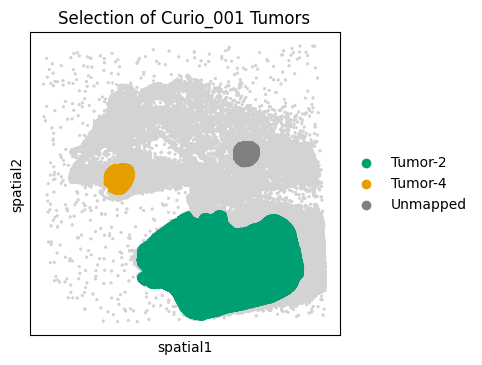

/Users/matthewjones/miniconda3/envs/kp-spatial/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/matthewjones/miniconda3/envs/kp-spatial/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


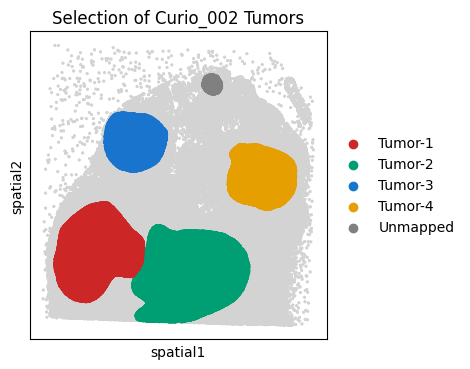

/Users/matthewjones/miniconda3/envs/kp-spatial/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/matthewjones/miniconda3/envs/kp-spatial/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


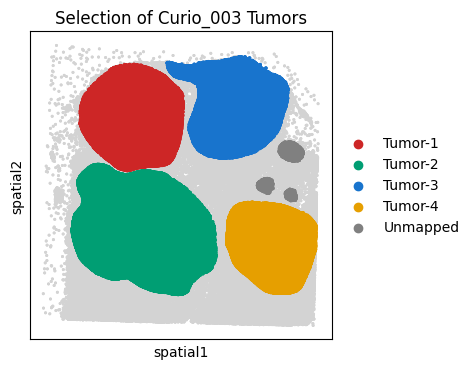

/Users/matthewjones/miniconda3/envs/kp-spatial/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/matthewjones/miniconda3/envs/kp-spatial/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


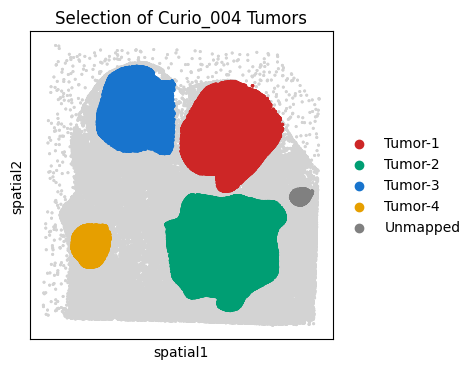

In [32]:
for _id in ['Curio_001', 'Curio_002', 'Curio_003', 'Curio_004']:

    fig = plt.figure(figsize=(4,4))
    ax = plt.gca()
    sq.pl.spatial_scatter(adata_combined, library_key='library_id', library_id=_id, size=5, shape=None, na_color='lightgray', ax=ax, figsize=(7,7), legend_loc=None)
    sq.pl.spatial_scatter(adata_combined, library_key='library_id', library_id=_id, color=['tumor_id-remapped'],
                          groups = [tumor for tumor in adata_combined.obs['tumor_id-remapped'].unique() if tumor != 'non-tumor'],
                          size=10, ax=ax, shape=None)
    plt.gca().invert_yaxis()
    plt.title(f'Selection of {_id} Tumors')
    # plt.savefig(f'figures/tumor_segmentation.{_id}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [37]:
#### SAVE ADATA ###
# adata_combined.write_h5ad("/path/to/save/adata_merged_layers.SPC-11.h5ad", compression='gzip')

# adata_combined[adata_combined.obs['library_id'].isin(['Curio_001','Curio_002', 'Curio_003', 'Curio_004'])].write_h5ad("/path/to/save/adata_merged_layers.SPC-11.curio.h5ad", compression='gzip')